### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤後快訊】前高賣壓，爆量中黑  
今天早上有活動出門(下跌跟我無關)，所以現在才有空整理資料，反正都收盤了，先簡單寫。  
周末和昨天提到，攻高過程有3個要件，其中之一是「強勢的族群能否維持續漲 AI概念股，在指數攻高過程，是最核心的動能，也是人氣之所在，所以必須同步持續上攻，不能有高檔出貨的技術面現象，例如爆量長黑或長上影線」。  
但很遺憾的，今天指數一創高，不少原先熱門股都出現大量甚至爆量的中長黑K現象，在高檔區不得不小心謹慎。如果持有這些出現高檔黑K的個股，晚上務必檢視籌碼變化，如果法人大賣融資大增，就要小心高檔出貨的風險。  
不過從指數觀察，從趨勢型態以及外資期現貨觀察，今天只能說是短線遇壓轉弱，還不算全面翻空，先簡單寫到這邊，明天早上再補充 (出處：K線捕手楊忠憲粉絲團)  

🏆楊忠憲 制霸台股！專業操盤手實戰攻略(每場限額50名)  
7/25(二)台北場：https://reurl.cc/7kMOO5  

### 本日進度  
  
* 力山(1515)現持有1張(**目前規劃僅試單1張**)，庫存現值36,900元(收盤價36.90：元，跌1.55元)。調整後的停損價為35.00元，目標價為42.50元。  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 未實現損益 #####
stock_gains_losses = [['1515','力山',1000,36351,36.35,36.9,36738,387,1.06]]
gains_losses_df = pd.DataFrame(stock_gains_losses,columns=['代碼', '股票名稱','即時庫存','付出成本','成本均價','現價','現值','損益試算','獲利率%'])
print('未實現損益：')
display(gains_losses_df)

未實現損益：


,代碼,股票名稱,即時庫存,付出成本,成本均價,現價,現值,損益試算,獲利率%
0,1515,力山,1000,36351,36.35,36.9,36738,387,1.06


In [3]:
##### 使用2022年3月11日到今日收盤價(2023年7月18日)之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_1515_230718.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 設定今天日期
today_date = df_k_line.iloc[-1]['Date'].strftime("%Y-%m-%d")

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

頸線價格 ＝ 35.00元 ， 開始日期 ＝ 2022-06-06 ， 結束日期 ＝ 2023-07-18
目標價 ＝ 42.50元


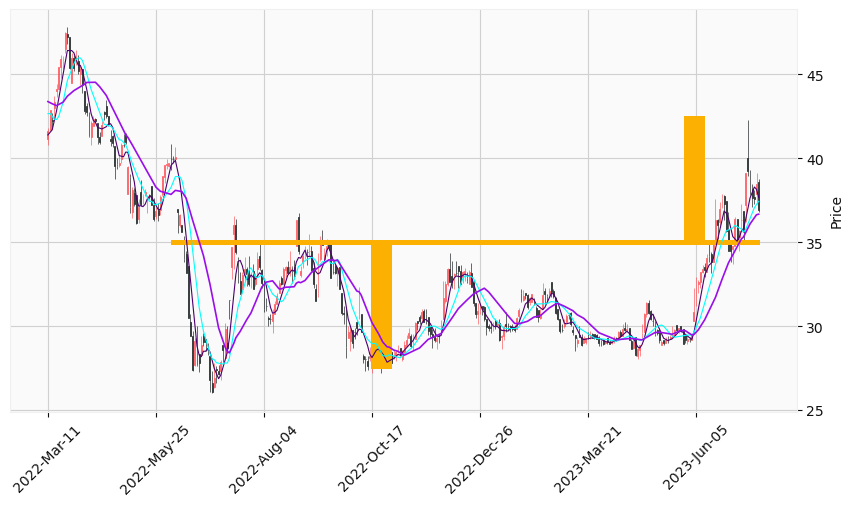

In [4]:
# 手動設定頸線
neckline_price = df_k_line.loc['2022-9-13']['Open']
neckline_start_date = '2022-06-06'
neckline_end_date = today_date
print('頸線價格 ＝ {:.2f}元 ， 開始日期 ＝ {} ， 結束日期 ＝ {}'.format(neckline_price,neckline_start_date,neckline_end_date))

# 估算目標價
bottom_price_date = '2022-10-21'
bottom_price = df_k_line.loc[bottom_price_date]['Close']
target_price = (neckline_price - bottom_price) + neckline_price
print('目標價 ＝ {:.2f}元'.format(target_price))
target_price_date = '2023-06-02'

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
    [(bottom_price_date,bottom_price),(bottom_price_date,neckline_price)],
    [(target_price_date,target_price),(target_price_date,neckline_price)]
                     ]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=1.2,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=(2.5,15,15), colors=('xkcd:yellow orange')))
mpf.plot(df_k_line,**kwargs)

                Date  Price Type
DateIndex                       
8         2022-03-23  47.45   HI
41        2022-05-12  36.15   LO
59        2022-06-08  40.10   HI
76        2022-07-01  26.10   LO
86        2022-07-15  36.05   HI
103       2022-08-09  30.40   LO
115       2022-08-25  36.30   HI
124       2022-09-07  31.50   LO
126       2022-09-12  34.90   HI
154       2022-10-21  27.50   LO
185       2022-12-05  33.40   HI
209       2023-01-09  29.20   LO
232       2023-02-21  32.10   HI
272       2023-04-25  28.30   LO
277       2023-05-03  31.35   HI
294       2023-05-26  28.95   LO
324       2023-07-11  40.00   HI


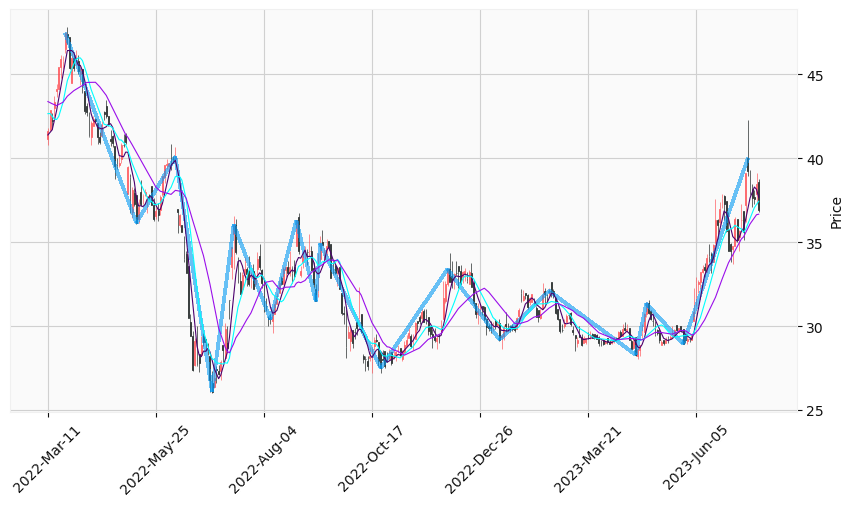

In [5]:
import myutils

# 尋找轉折點
_,_,max_min = myutils.FindingTurningPoints(df_k_line,'close',order=10,real_body=True)
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定轉折線
seq_of_seq_of_points = []
for _current in range(0,len(max_min)) :
    _next = _current + 1
    if _next < len(max_min) :
        seq_of_seq_of_points.append([(max_min.iloc[_current]['Date'],max_min.iloc[_current]['Price']),(max_min.iloc[_next]['Date'],max_min.iloc[_next]['Price'])])
    else :
        break
        
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.8,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=2.0, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

                Date  Price Type
DateIndex                       
8         2022-03-23  47.45   HI
41        2022-05-12  36.15   LO
59        2022-06-08  40.10   HI
67        2022-06-20  27.40   LO
68        2022-06-21  29.10   HI
76        2022-07-01  26.10   LO
86        2022-07-15  36.05   HI
89        2022-07-20  31.90   LO
97        2022-08-01  34.00   HI
103       2022-08-09  30.40   LO
115       2022-08-25  36.30   HI
124       2022-09-07  31.50   LO
126       2022-09-12  34.90   HI
138       2022-09-28  28.75   LO
144       2022-10-06  30.75   HI
148       2022-10-13  27.60   LO
151       2022-10-18  29.20   HI
154       2022-10-21  27.50   LO
173       2022-11-17  30.85   HI
179       2022-11-25  29.20   LO
185       2022-12-05  33.40   HI
209       2023-01-09  29.20   LO
232       2023-02-21  32.10   HI
272       2023-04-25  28.30   LO
277       2023-05-03  31.35   HI
294       2023-05-26  28.95   LO
312       2023-06-21  37.65   HI
315       2023-06-28  34.50   LO
324       

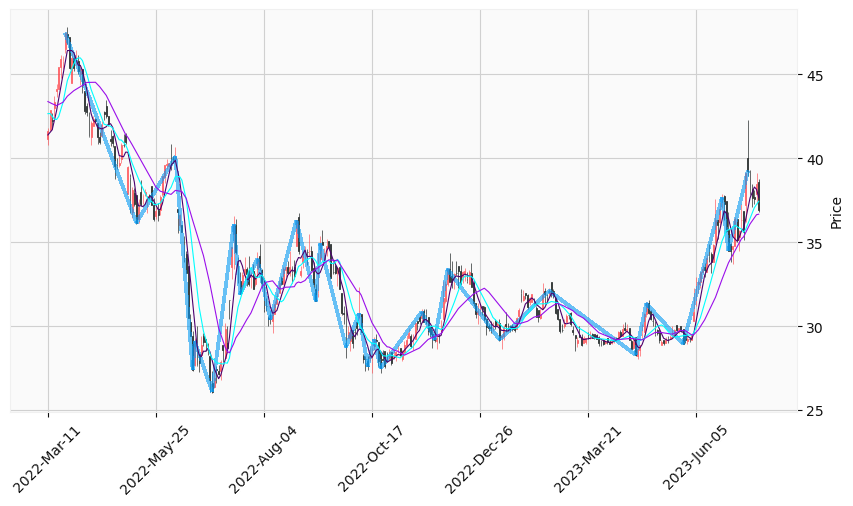

In [6]:
# 尋找方向變化點 (ZigZag)
_,_,max_min = myutils.FindingDirectionalChangePoints(df_k_line,percentage=5,mode='close')
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定轉折線
seq_of_seq_of_points = []
for _current in range(0,len(max_min)) :
    _next = _current + 1
    if _next < len(max_min) :
        seq_of_seq_of_points.append([(max_min.iloc[_current]['Date'],max_min.iloc[_current]['Price']),(max_min.iloc[_next]['Date'],max_min.iloc[_next]['Price'])])
    else :
        break
        
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.8,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=2.0, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

                Date  Price Type
DateIndex                       
8         2022-03-23  47.45   HI
41        2022-05-12  36.15   LO
59        2022-06-08  40.10   HI
76        2022-07-01  26.10   LO
86        2022-07-15  36.05   HI
103       2022-08-09  30.40   LO
115       2022-08-25  36.30   HI
124       2022-09-07  31.50   LO
126       2022-09-12  34.90   HI
154       2022-10-21  27.50   LO
185       2022-12-05  33.40   HI
209       2023-01-09  29.20   LO
232       2023-02-21  32.10   HI
272       2023-04-25  28.30   LO
277       2023-05-03  31.35   HI
294       2023-05-26  28.95   LO
312       2023-06-21  37.65   HI
315       2023-06-28  34.50   LO


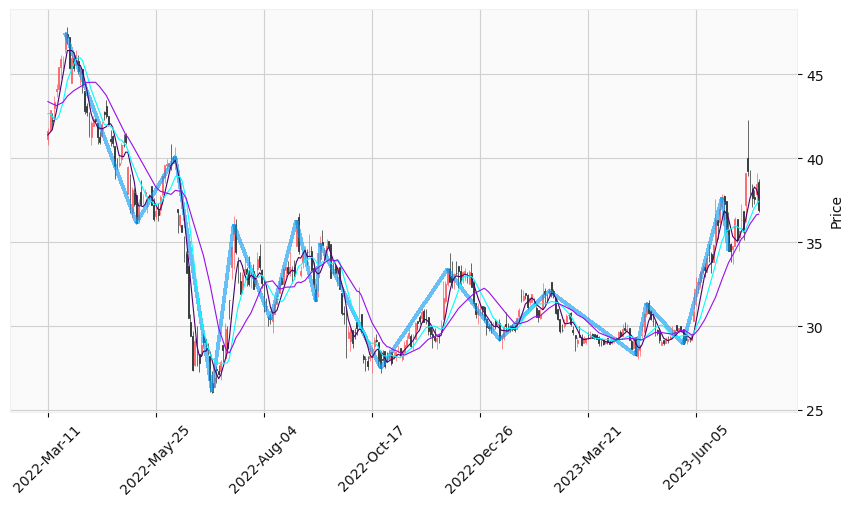

In [7]:
# 尋找方向變化點 (ZigZag)
_,_,max_min = myutils.FindingDirectionalChangePoints(df_k_line,percentage=7,mode='close')
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定轉折線
seq_of_seq_of_points = []
for _current in range(0,len(max_min)) :
    _next = _current + 1
    if _next < len(max_min) :
        seq_of_seq_of_points.append([(max_min.iloc[_current]['Date'],max_min.iloc[_current]['Price']),(max_min.iloc[_next]['Date'],max_min.iloc[_next]['Price'])])
    else :
        break
        
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.8,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=2.0, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

                Date  Price
DateIndex                  
0         2022-03-11  41.60
8         2022-03-23  47.45
19        2022-04-11  41.30
36        2022-05-05  40.95
41        2022-05-12  36.15
59        2022-06-08  40.10
67        2022-06-20  27.40
73        2022-06-28  29.05
76        2022-07-01  26.10
83        2022-07-12  28.70
86        2022-07-15  36.05
89        2022-07-20  31.90
97        2022-08-01  34.00
103       2022-08-09  30.40
114       2022-08-24  33.00
115       2022-08-25  36.30
124       2022-09-07  31.50
130       2022-09-16  34.70
138       2022-09-28  28.75
154       2022-10-21  27.50
180       2022-11-28  29.30
185       2022-12-05  33.40
209       2023-01-09  29.20
232       2023-02-21  32.10
294       2023-05-26  28.95
312       2023-06-21  37.65
315       2023-06-28  34.50
322       2023-07-07  35.60
323       2023-07-10  39.15
329       2023-07-18  36.90


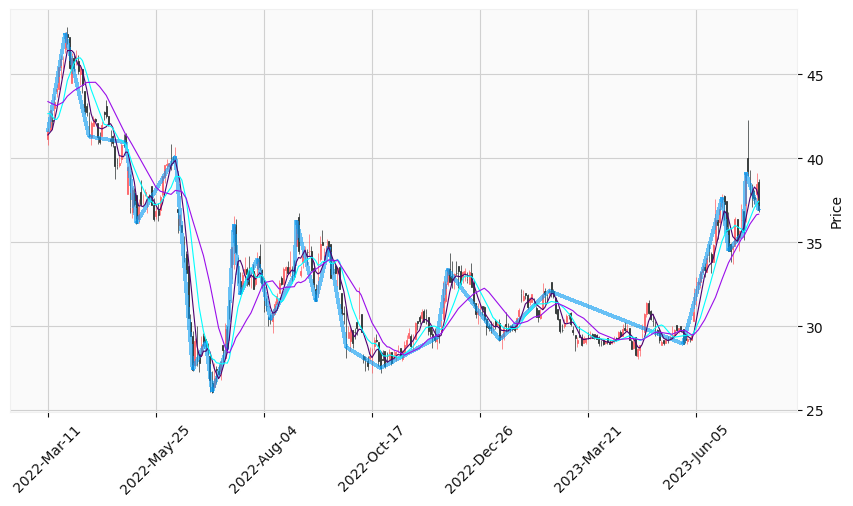

In [8]:
# 尋找感知重要點
pips = myutils.FindingPerceptuallyImportantPoints(df_k_line,n_pips=30)
print(pips)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定轉折線
seq_of_seq_of_points = []
for _current in range(0,len(pips)) :
    _next = _current + 1
    if _next < len(pips) :
        seq_of_seq_of_points.append([(pips.iloc[_current]['Date'],pips.iloc[_current]['Price']),(pips.iloc[_next]['Date'],pips.iloc[_next]['Price'])])
    else :
        break
        
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.8,color='xkcd:royal purple'),
    "SMA10": mpf.make_addplot(df_sma['SMA10'],width=0.8,color='xkcd:cyan'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.8,color='xkcd:violet')
            }

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()),alines=dict(alines=seq_of_seq_of_points, linewidths=2.0, colors='xkcd:azure', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

* [誠品](https://events.eslite.com/)  
  - [讓證據說話的技術分析 上](https://www.eslite.com/product/1001129781795046)  
  - [買在起漲點](https://www.eslite.com/product/1001129782375204)  
  - [賣在起跌點](https://www.eslite.com/product/1001129782375205)  
* 參考：[Technical Analysis for Algorithmic Pattern Recognition](https://link.springer.com/book/10.1007/978-3-319-23636-0)（[下載](https://tinyurl.com/jhh94x7r)）  

* 本月將進行整合先前完成的程式碼(轉折點、頭肩底型態與趨勢線…等)與[neurotrader](https://www.youtube.com/@neurotrader888/videos)之程式碼：  
  - 位階  
    + [量化位階評價法](https://vocus.cc/article/62ada936fd89780001fe6208) ： 完成 **StockRankEvaluate** 類別 \[已整合進**myutils套件**\]
  - 轉折點  
    + 峰位∕谷底的演變程序([peak-and-trough progression](https://www.amazon.com/Technical-Analysis-Explained-Fifth-Successful/dp/0071825177)) 與 滾動窗口([Rolling Window](https://www.youtube.com/watch?v=X31hyMhB-3s&t=49s)) ： 已完成 **FindingTurningPoints()** 函式 \[已整合進**myutils套件**\]
    + 方向變化([Directional Change](https://www.youtube.com/watch?v=X31hyMhB-3s&t=179s)) ： [directional_change.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/directional_change.py) 已完成 **FindingDirectionalChangePoints()** 函式 \[已整合進**myutils套件**\]  
    + 感知重要點([Perceptually Important Points](https://www.youtube.com/watch?v=X31hyMhB-3s&t=339s)) ： [perceptually_important.py](https://tinyurl.com/yc2bykhr) 已完成**FindingPerceptuallyImportantPoints()** 函式 \[已整合進**myutils套件**\]  
  - 趨勢線  
    + 自行開發 ： 模擬手工方式，由兩個轉折點中畫出一條趨勢線  
    + 自動價格趨勢線([Automated Price Trend Lines](https://www.youtube.com/watch?v=wbFoefnidTU)) ： [trendline_automation.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/trendline_automation.py)  
  - 型態  
    + 頭肩底(或 頭肩頂)演算法一([Algorithmically Detecting (and Trading) Technical Chart Patterns with Python](https://medium.com/automation-generation/algorithmically-detecting-and-trading-technical-chart-patterns-with-python-c577b3a396ed)) ： [tech_screener_notebook.ipynb](https://github.com/samchaaa/alpaca_tech_screener/blob/master/tech_screener_notebook.ipynb) ： 頭肩底函式已完成，待整理 
    + 頭肩底(或 頭肩頂)演算法二([Automated Head and Shoulders Chart Pattern in Python](https://www.youtube.com/watch?v=6iFqjd5BOHw)) ： [head_shoulders.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/head_shoulders.py) 
    + 旗型與三角旗型演算法([Flag and Pennant Pattern Recognition](https://www.youtube.com/watch?v=Lb5SPCTp4uY)) ： [flags_pennants.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/flags_pennants.py)  